In [32]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm optuna


Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import VotingClassifier

import xgboost as xgb
import lightgbm as lgb

import optuna

In [34]:
df = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [35]:
df.shape

(1190, 12)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [37]:
df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [38]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


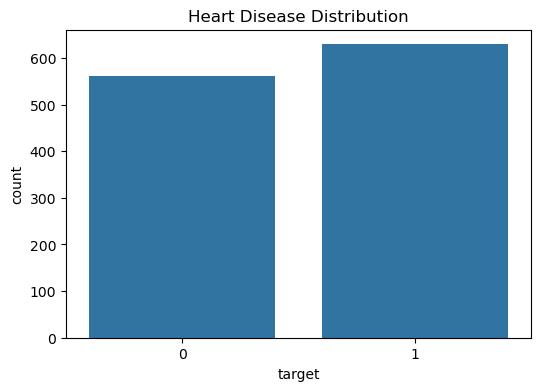

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")

plt.show()

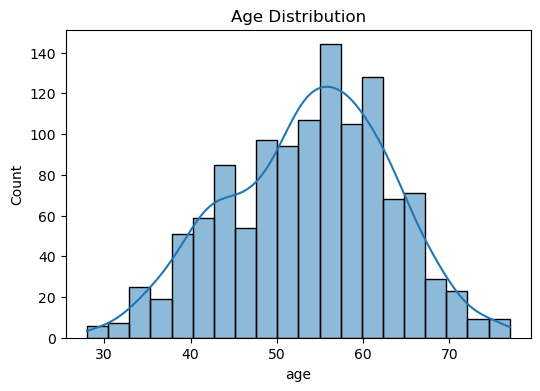

In [40]:
plt.figure(figsize=(6,4))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

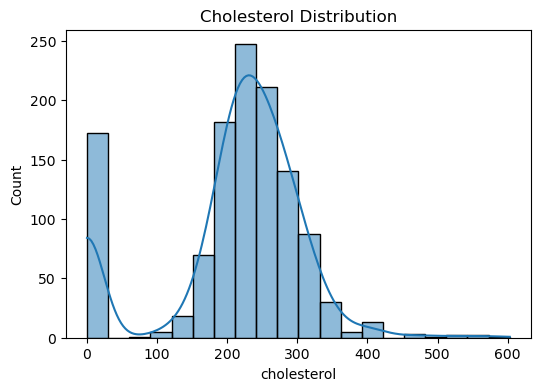

In [41]:
plt.figure(figsize=(6,4))

sns.histplot(df["cholesterol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")

plt.show()

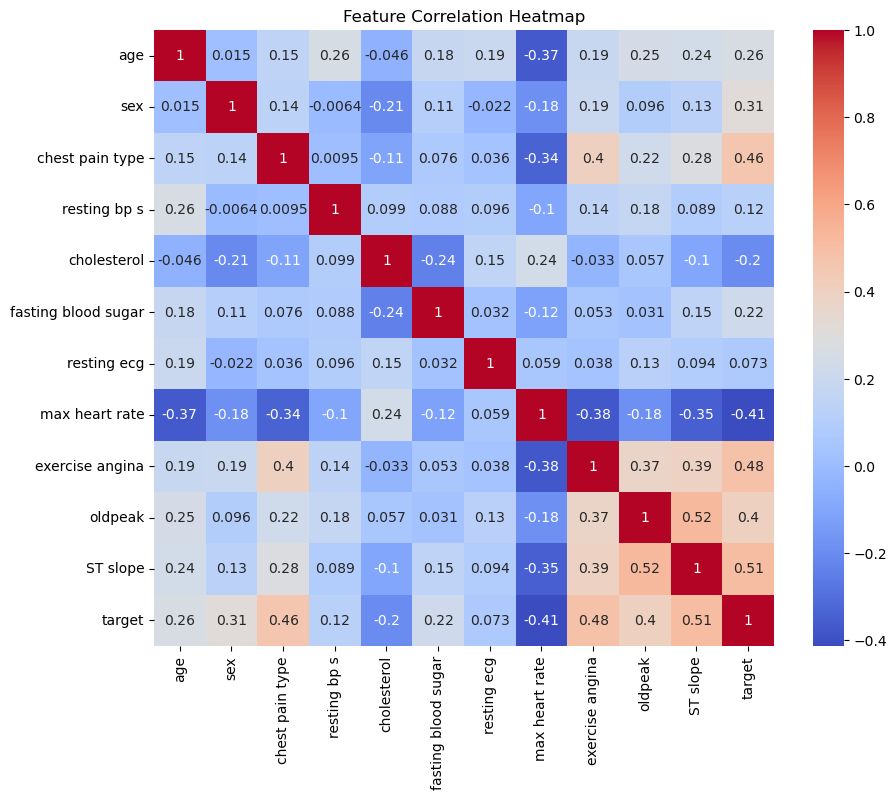

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [60]:
X = df.drop("target", axis=1)

y = df["target"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# XGB base

In [63]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import f1_score

In [64]:
xgb_base = xgb.XGBClassifier()

xgb_base.fit(X_train, y_train)

xgb_pred = xgb_base.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

xgb_f1=f1_score(  y_test, xgb_pred)

print("Baseline XGBoost Accuracy:", xgb_acc)

print("Baseline XGBoost F1 Score:", xgb_f1)

Baseline XGBoost Accuracy: 0.9285714285714286
Baseline XGBoost F1 Score: 0.9358490566037736


# lgb BASE

In [66]:
lgb_base = lgb.LGBMClassifier()

lgb_base.fit(X_train, y_train)

lgb_pred = lgb_base.predict(X_test)

lgb_acc = accuracy_score(y_test, lgb_pred)

lgb_f1=f1_score( y_test, lgb_pred)

print("base lgb accuracy",lgb_acc)
print("base lgb f1 score",lgb_f1)


base lgb accuracy 0.9453781512605042
base lgb f1 score 0.9505703422053232


# Ensemble Model

In [67]:
weights_list = [[2,1], [1,2], [2,3], [3,2],[1,3],[3,1]]

for w in weights_list:
    ensemble = VotingClassifier(
        estimators=[
            ('xgb', xgb_base),
            ('lgb', lgb_base)
        ],
        voting='soft',
        weights=w
    )
    
    ensemble.fit(X_train, y_train)
    pred = ensemble.predict(X_test)
    
    print("Weights:", w, "Accuracy:", accuracy_score(y_test, pred))
    print("Weights:", w, "F1 Score:", f1_score(y_test, pred))   

Weights: [2, 1] Accuracy: 0.9453781512605042
Weights: [2, 1] F1 Score: 0.9505703422053232
Weights: [1, 2] Accuracy: 0.9411764705882353
Weights: [1, 2] F1 Score: 0.9465648854961832
Weights: [2, 3] Accuracy: 0.9411764705882353
Weights: [2, 3] F1 Score: 0.9465648854961832
Weights: [3, 2] Accuracy: 0.9453781512605042
Weights: [3, 2] F1 Score: 0.9505703422053232
Weights: [1, 3] Accuracy: 0.9411764705882353
Weights: [1, 3] F1 Score: 0.9465648854961832
Weights: [3, 1] Accuracy: 0.9369747899159664
Weights: [3, 1] F1 Score: 0.9433962264150944


In [68]:
ensemble_base = VotingClassifier(
    estimators=[
        ("xgb", xgb_base),
        ("lgb", lgb_base)
    ],
    voting="soft",
    weights=[3,2]
)

ensemble_base.fit(X_train, y_train)

ensemble_pred = ensemble_base.predict(X_test)

ensemble_acc = accuracy_score(y_test, ensemble_pred)

print("Baseline Ensemble Accuracy:", ensemble_acc)
print("Baseline Ensemble F1 Score:", f1_score(y_test, ensemble_pred))

Baseline Ensemble Accuracy: 0.9453781512605042
Baseline Ensemble F1 Score: 0.9505703422053232


# tuning

In [69]:
import warnings
warnings.filterwarnings("ignore")

import optuna
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

In [70]:
def xgb_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = xgb.XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    return score


study_xgb = optuna.create_study(direction="maximize")

study_xgb.optimize(xgb_objective, n_trials=60)

best_xgb_params = study_xgb.best_params

print("Best XGBoost Parameters:", best_xgb_params)

Best XGBoost Parameters: {'n_estimators': 306, 'max_depth': 7, 'learning_rate': 0.09687187077845644, 'subsample': 0.6156943738789316, 'colsample_bytree': 0.6075020317706383}


In [75]:
xgb_opt = xgb.XGBClassifier(**best_xgb_params)

xgb_opt.fit(X_train, y_train)

xgb_opt_pred = xgb_opt.predict(X_test)

xgb_opt_acc = accuracy_score(y_test, xgb_opt_pred)

xgb_opt_f1=f1_score(y_test, xgb_opt_pred)

print("Optimized XGBoost Accuracy:", xgb_opt_acc)
print("Optimized XGBoost F1 Score:", xgb_opt_f1)

Optimized XGBoost Accuracy: 0.9453781512605042
Optimized XGBoost F1 Score: 0.9505703422053232


In [76]:
def lgb_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150)
    }

    model = lgb.LGBMClassifier(**params,verbosity=-1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    return score


study_lgb = optuna.create_study(direction="maximize")

study_lgb.optimize(lgb_objective, n_trials=60)

best_lgb_params = study_lgb.best_params

print("Best LightGBM Parameters:", best_lgb_params)

Best LightGBM Parameters: {'n_estimators': 321, 'max_depth': 10, 'learning_rate': 0.18169781219667985, 'num_leaves': 53}


In [77]:
lgb_opt = lgb.LGBMClassifier(**best_lgb_params)

lgb_opt.fit(X_train, y_train)

lgb_opt_pred = lgb_opt.predict(X_test)

lgb_opt_acc = accuracy_score(y_test, lgb_opt_pred)

lgb_opt_f1=f1_score(y_test, lgb_opt_pred)

print("Optimized LightGBM Accuracy:", lgb_opt_acc)
print("Optimized LightGBM F1 Score:", lgb_opt_f1)

Optimized LightGBM Accuracy: 0.9453781512605042
Optimized LightGBM F1 Score: 0.9505703422053232


In [78]:
ensemble_opt = VotingClassifier(
    estimators=[
        ("xgb", xgb_opt),
        ("lgb", lgb_opt)
    ],
    voting="soft"
)

ensemble_opt.fit(X_train, y_train)

ensemble_opt_pred = ensemble_opt.predict(X_test)

ensemble_opt_acc = accuracy_score(y_test, ensemble_opt_pred)

ensemble_opt_f1=f1_score(y_test, ensemble_opt_pred)

print("Optimized Ensemble Accuracy:", ensemble_opt_acc)
print("Optimized Ensemble F1 Score:", ensemble_opt_f1)

Optimized Ensemble Accuracy: 0.9495798319327731
Optimized Ensemble F1 Score: 0.9545454545454546


In [80]:

for i in range(1,7):
    for j in range(1,7):

        ensemble = VotingClassifier(
        estimators=[
            ('xgb', xgb_opt),
            ('lgb', lgb_opt)
        ],
        voting='soft',
        weights=[i, j]
        )
    
        ensemble.fit(X_train, y_train)
        pred = ensemble.predict(X_test)
    
        print("Weights:", [i, j], "Accuracy:", accuracy_score(y_test, pred))
        print("weights:", [i, j], "f1 :", f1_score(y_test, pred))

Weights: [1, 1] Accuracy: 0.9495798319327731
weights: [1, 1] f1 : 0.9545454545454546
Weights: [1, 2] Accuracy: 0.9453781512605042
weights: [1, 2] f1 : 0.9505703422053232
Weights: [1, 3] Accuracy: 0.9411764705882353
weights: [1, 3] f1 : 0.9465648854961832
Weights: [1, 4] Accuracy: 0.9411764705882353
weights: [1, 4] f1 : 0.9465648854961832
Weights: [1, 5] Accuracy: 0.9411764705882353
weights: [1, 5] f1 : 0.9465648854961832
Weights: [1, 6] Accuracy: 0.9411764705882353
weights: [1, 6] f1 : 0.9465648854961832
Weights: [2, 1] Accuracy: 0.9495798319327731
weights: [2, 1] f1 : 0.9545454545454546
Weights: [2, 2] Accuracy: 0.9495798319327731
weights: [2, 2] f1 : 0.9545454545454546
Weights: [2, 3] Accuracy: 0.9495798319327731
weights: [2, 3] f1 : 0.9545454545454546
Weights: [2, 4] Accuracy: 0.9453781512605042
weights: [2, 4] f1 : 0.9505703422053232
Weights: [2, 5] Accuracy: 0.9453781512605042
weights: [2, 5] f1 : 0.9505703422053232
Weights: [2, 6] Accuracy: 0.9411764705882353
weights: [2, 6] f1 :

In [81]:
ensemble_opt = VotingClassifier(
    estimators=[
        ("xgb", xgb_opt),
        ("lgb", lgb_opt)
    ],
    voting="soft",
    weights=[1,1]
)

ensemble_opt.fit(X_train, y_train)

ensemble_opt_pred = ensemble_opt.predict(X_test)

ensemble_opt_acc = accuracy_score(y_test, ensemble_opt_pred)

ensemble_opt_f1=f1_score(y_test, ensemble_opt_pred)

print("Optimized Ensemble Accuracy:", ensemble_opt_acc)
print("Optimized Ensemble F1 Score:", ensemble_opt_f1)


Optimized Ensemble Accuracy: 0.9495798319327731
Optimized Ensemble F1 Score: 0.9545454545454546


In [82]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve


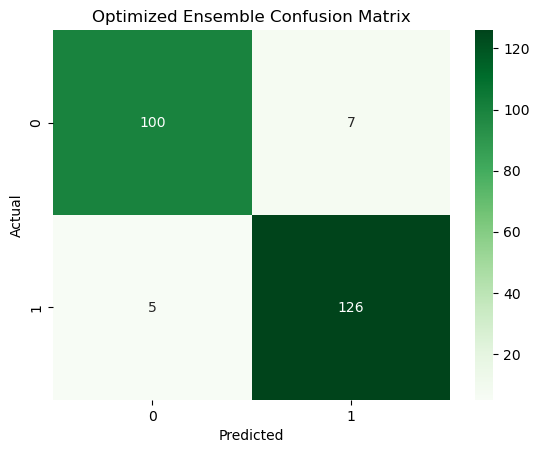

In [83]:
cm = confusion_matrix(y_test, ensemble_opt_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Optimized Ensemble Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [84]:
print(classification_report(y_test, ensemble_opt_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       107
           1       0.95      0.96      0.95       131

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238



In [85]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [86]:
y_prob = ensemble_opt.predict_proba(X_test)[:,1]


In [87]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

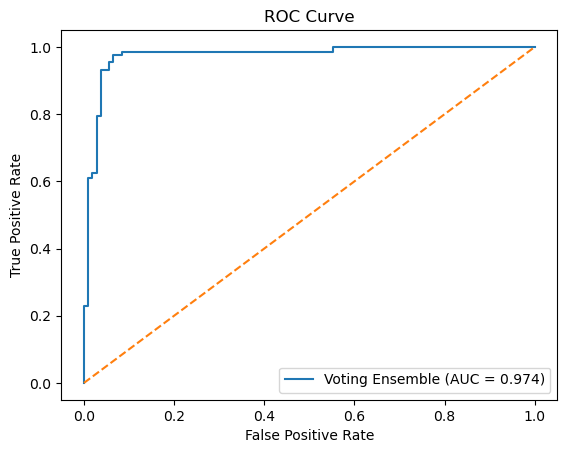

In [88]:
plt.figure()

plt.plot(fpr, tpr, label="Voting Ensemble (AUC = %0.3f)" % auc_score)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [90]:
for i in range(1,7):
    for j in range(1,7):
        ensemble = VotingClassifier(
            estimators=[
                ('lgb', lgb_base),
                ('xgb', xgb_opt)
            ],
            voting='soft',
            weights=[i, j]
        )
        
        ensemble.fit(X_train, y_train)
        pred = ensemble.predict(X_test)
        
        print("Weights:", [i, j], "Accuracy:", accuracy_score(y_test, pred))
        print("weights:", [i, j], "f1 :", f1_score(y_test, pred))   


Weights: [1, 1] Accuracy: 0.9495798319327731
weights: [1, 1] f1 : 0.9545454545454546
Weights: [1, 2] Accuracy: 0.9453781512605042
weights: [1, 2] f1 : 0.9505703422053232
Weights: [1, 3] Accuracy: 0.9495798319327731
weights: [1, 3] f1 : 0.9545454545454546
Weights: [1, 4] Accuracy: 0.9495798319327731
weights: [1, 4] f1 : 0.9545454545454546
Weights: [1, 5] Accuracy: 0.9495798319327731
weights: [1, 5] f1 : 0.9545454545454546
Weights: [1, 6] Accuracy: 0.9495798319327731
weights: [1, 6] f1 : 0.9545454545454546
Weights: [2, 1] Accuracy: 0.9495798319327731
weights: [2, 1] f1 : 0.9545454545454546
Weights: [2, 2] Accuracy: 0.9495798319327731
weights: [2, 2] f1 : 0.9545454545454546
Weights: [2, 3] Accuracy: 0.9495798319327731
weights: [2, 3] f1 : 0.9545454545454546
Weights: [2, 4] Accuracy: 0.9453781512605042
weights: [2, 4] f1 : 0.9505703422053232
Weights: [2, 5] Accuracy: 0.9453781512605042
weights: [2, 5] f1 : 0.9505703422053232
Weights: [2, 6] Accuracy: 0.9495798319327731
weights: [2, 6] f1 :

In [91]:
for i in range(1,6):
    for j in range(1,6):
        ensemble = VotingClassifier(
            estimators=[
                ('lgb', lgb_opt),
                ('xgb', xgb_base)
            ],
            voting='soft',
            weights=[i, j]
        )
        
        ensemble.fit(X_train, y_train)
        pred = ensemble.predict(X_test)
        
        print([i, j], accuracy_score(y_test, pred))
        print([i, j], f1_score(y_test, pred))

[1, 1] 0.9453781512605042
[1, 1] 0.9505703422053232
[1, 2] 0.9495798319327731
[1, 2] 0.9545454545454546
[1, 3] 0.9495798319327731
[1, 3] 0.9545454545454546
[1, 4] 0.9411764705882353
[1, 4] 0.9473684210526315
[1, 5] 0.9369747899159664
[1, 5] 0.9433962264150944
[2, 1] 0.9411764705882353
[2, 1] 0.9465648854961832
[2, 2] 0.9453781512605042
[2, 2] 0.9505703422053232
[2, 3] 0.9495798319327731
[2, 3] 0.9545454545454546
[2, 4] 0.9495798319327731
[2, 4] 0.9545454545454546
[2, 5] 0.9495798319327731
[2, 5] 0.9545454545454546
[3, 1] 0.9411764705882353
[3, 1] 0.9465648854961832
[3, 2] 0.9453781512605042
[3, 2] 0.9505703422053232
[3, 3] 0.9453781512605042
[3, 3] 0.9505703422053232
[3, 4] 0.9495798319327731
[3, 4] 0.9545454545454546
[3, 5] 0.9495798319327731
[3, 5] 0.9545454545454546
[4, 1] 0.9411764705882353
[4, 1] 0.9465648854961832
[4, 2] 0.9411764705882353
[4, 2] 0.9465648854961832
[4, 3] 0.9453781512605042
[4, 3] 0.9505703422053232
[4, 4] 0.9453781512605042
[4, 4] 0.9505703422053232
[4, 5] 0.945

In [92]:
for i in range(1,6):
    for j in range(1,6):
        ensemble = VotingClassifier(
            estimators=[
                ('lgb', lgb_opt),
                ('xgb', xgb_base)
            ],
            voting='soft',
            weights=[i, j]
        )
        
        ensemble.fit(X_train, y_train)
        pred = ensemble.predict(X_test)
        
        print([i, j], accuracy_score(y_test, pred))
        print([i, j], f1_score(y_test, pred))

[1, 1] 0.9453781512605042
[1, 1] 0.9505703422053232
[1, 2] 0.9495798319327731
[1, 2] 0.9545454545454546
[1, 3] 0.9495798319327731
[1, 3] 0.9545454545454546
[1, 4] 0.9411764705882353
[1, 4] 0.9473684210526315
[1, 5] 0.9369747899159664
[1, 5] 0.9433962264150944
[2, 1] 0.9411764705882353
[2, 1] 0.9465648854961832
[2, 2] 0.9453781512605042
[2, 2] 0.9505703422053232
[2, 3] 0.9495798319327731
[2, 3] 0.9545454545454546
[2, 4] 0.9495798319327731
[2, 4] 0.9545454545454546
[2, 5] 0.9495798319327731
[2, 5] 0.9545454545454546
[3, 1] 0.9411764705882353
[3, 1] 0.9465648854961832
[3, 2] 0.9453781512605042
[3, 2] 0.9505703422053232
[3, 3] 0.9453781512605042
[3, 3] 0.9505703422053232
[3, 4] 0.9495798319327731
[3, 4] 0.9545454545454546
[3, 5] 0.9495798319327731
[3, 5] 0.9545454545454546
[4, 1] 0.9411764705882353
[4, 1] 0.9465648854961832
[4, 2] 0.9411764705882353
[4, 2] 0.9465648854961832
[4, 3] 0.9453781512605042
[4, 3] 0.9505703422053232
[4, 4] 0.9453781512605042
[4, 4] 0.9505703422053232
[4, 5] 0.945

# final model

In [93]:
ensemble_opt = VotingClassifier(
    estimators=[
        ("xgb", xgb_opt),
        ("lgb", lgb_opt)
    ],
    voting="soft",
    weights=[1,1]
)

ensemble_opt.fit(X_train, y_train)

ensemble_opt_pred = ensemble_opt.predict(X_test)

ensemble_opt_acc = accuracy_score(y_test, ensemble_opt_pred)

print("Optimized Ensemble Accuracy:", ensemble_opt_acc)

print("f1 score:",f1_score(y_test,ensemble_opt_pred))

Optimized Ensemble Accuracy: 0.9495798319327731
f1 score: 0.9545454545454546


In [94]:
import joblib

# Specify the filename for your ensemble model
model_filename = "heart_disease_voting_ensemble.pkl"

# Save the entire fitted ensemble model to disk
joblib.dump(ensemble_opt, model_filename)

print(f"🎉 Success! Your optimized ensemble model has been exported as '{model_filename}'")

🎉 Success! Your optimized ensemble model has been exported as 'heart_disease_voting_ensemble.pkl'


# SHAP LIME

In [95]:
pip install shap lime

Note: you may need to restart the kernel to use updated packages.


In [96]:
import shap

In [97]:
feature_names = X.columns
X_test_df= pd.DataFrame(X_test, columns=feature_names)

In [98]:
explainer = shap.TreeExplainer(xgb_opt)  

In [99]:
shap_values = explainer.shap_values(X_test_df)

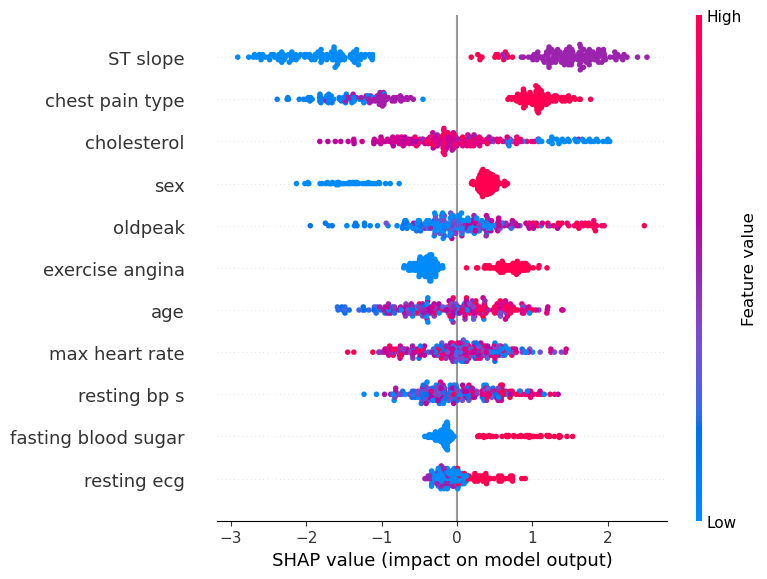

In [100]:
shap.summary_plot(shap_values, X_test_df)

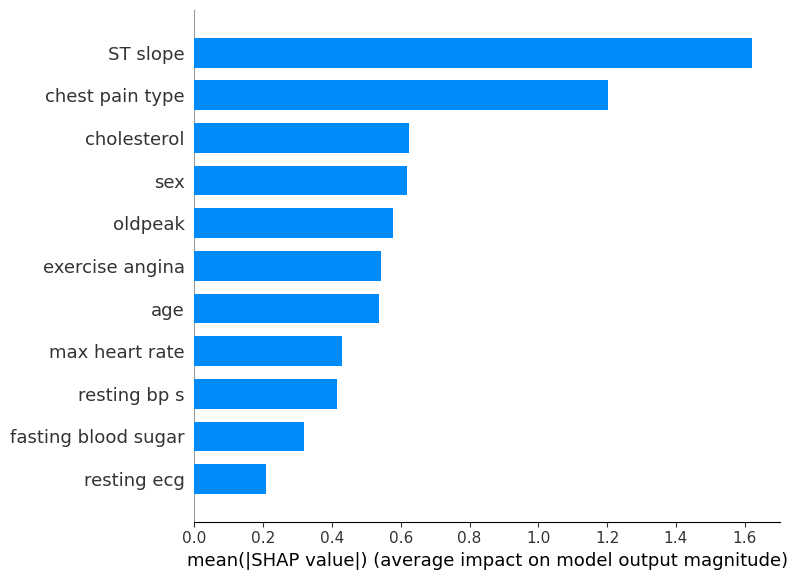

In [101]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

In [102]:
shap.initjs()

In [103]:
sample_index = 0

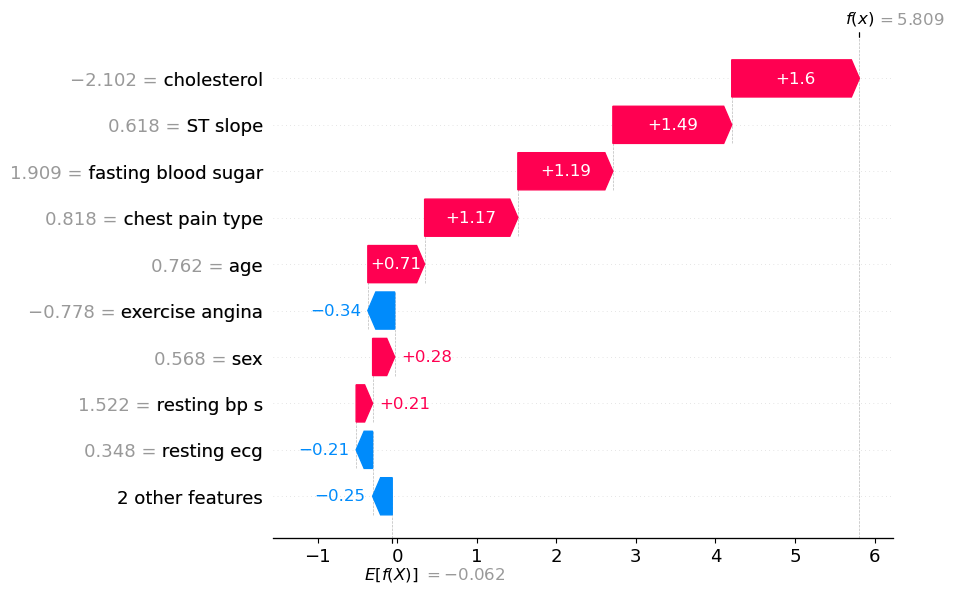

In [104]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[sample_index],
        feature_names=X_test_df.columns
    )
)

In [105]:
from lime.lime_tabular import LimeTabularExplainer

In [106]:
from IPython.display import display, HTML  

In [107]:
X_train_df= pd.DataFrame(X_train, columns=X.columns)

In [108]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X_train_df.columns,
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

In [109]:
# Run this inside your training notebook to export data ranges
# Assuming 'X_train' is your training pandas DataFrame or NumPy array containing the 11 columns
import pandas as pd
df_sample = pd.DataFrame(X_train, columns=[
    "Age", "Sex", "chest pain type", "resting bp s", "cholesterol",
    "fasting blood sugar", "resting ecg", "max heart rate", 
    "exercise angina", "oldpeak", "ST slope"
])
# Save just the first 100 rows to keep things lightweight
df_sample.head(100).to_csv("lime_training_background.csv", index=False)
print("Background statistics exported successfully!")

Background statistics exported successfully!
